# **PYTHON ANALYTICS**

## Installation of required libraries

In [ ]:
!pip install matplotlib seaborn pandas numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


print("Loaded the below version successfully")
print("  Pandas     - ", pd.__version__)
print("  NumPy      - ", np.__version__)
print("  Matplotlib - ", plt.matplotlib.__version__)
print("  Seaborn    - ", sns.__version__)

Loaded the below version successfully
  Pandas     -  2.2.2
  NumPy      -  2.0.2
  Matplotlib -  3.10.0
  Seaborn    -  0.13.2


## Loading the Data

In [ ]:
raw_data_url = "https://raw.githubusercontent.com/dheerium/northstar-analytics/main/data/"

ns_orders     = pd.read_csv(raw_data_url + "orders.csv")
ns_deliveries = pd.read_csv(raw_data_urlE + "deliveries.csv")
ns_customers  = pd.read_csv(raw_data_url + "customers.csv")
ns_drivers    = pd.read_csv(raw_data_url + "drivers.csv")
ns_vehicles   = pd.read_csv(raw_data_url + "vehicles.csv")
ns_incidents  = pd.read_csv(raw_data_url + "incidents.csv")
ns_complaints = pd.read_csv(raw_data_url + "complaints.csv")
ns_app_events = pd.read_csv(raw_data_url + "app_events.csv")
ns_hubs       = pd.read_csv(raw_data_url + "hubs.csv")

print("......Loaded Successfully......")
print(f"  orders:     {ns_orders.shape}")
print(f"  deliveries: {ns_deliveries.shape}")
print(f"  customers:  {ns_customers.shape}")
print(f"  drivers:    {ns_drivers.shape}")
print(f"  vehicles:   {ns_vehicles.shape}")
print(f"  incidents:  {ns_incidents.shape}")
print(f"  complaints: {ns_complaints.shape}")
print(f"  app_events: {ns_app_events.shape}")
print(f"  hubs:       {ns_hubs.shape}")

......Loaded Successfully......
  orders:     (1250, 11)
  deliveries: (950, 13)
  customers:  (650, 9)
  drivers:    (170, 8)
  vehicles:   (120, 8)
  incidents:  (280, 7)
  complaints: (320, 10)
  app_events: (640, 10)
  hubs:       (8, 5)


## Data Cleaning

### Code

In [ ]:
# Missing values before cleaning
print("&=&" * 20)
print("          MISSING VALUES — PRE-CLEANING REPORT")
print("&=&" * 20)

ns_datasets = {'ns_deliveries': ns_deliveries, 'ns_customers': ns_customers,'ns_drivers': ns_drivers,'ns_vehicles': ns_vehicles,'ns_incidents':  ns_incidents,'ns_complaints': ns_complaints}

for name, df in ns_datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print("\n" + name + ":")
        for col, count in missing.items():
            pct = round(count / len(df) * 100, 2)
            print(" ", col, "->", count, "missing (" + str(pct) + "%)")


# Standardising categorical columns
ns_orders['pickup_zone']          = ns_orders['pickup_zone'].str.strip().str.title()
ns_orders['dropoff_zone']         = ns_orders['dropoff_zone'].str.strip().str.title()
ns_drivers['base_zone']           = ns_drivers['base_zone'].str.strip().str.title()
ns_hubs['zone']                   = ns_hubs['zone'].str.strip().str.title()
ns_orders['service_type']         = ns_orders['service_type'].str.strip().str.title()
ns_orders['priority_level']       = ns_orders['priority_level'].str.strip().str.title()
ns_orders['booking_channel']      = ns_orders['booking_channel'].str.strip().str.title()
ns_deliveries['delivery_status']  = ns_deliveries['delivery_status'].str.strip()
ns_drivers['employment_type']     = ns_drivers['employment_type'].str.strip().str.title()
ns_drivers['shift_preference']    = ns_drivers['shift_preference'].str.strip().str.title()
ns_orders['pickup_zone']          = ns_orders['pickup_zone'].replace('Ctr', 'Central')
ns_orders['dropoff_zone']         = ns_orders['dropoff_zone'].replace('Ctr', 'Central')


# Filling missing values
ns_deliveries['customer_rating_post_delivery'].fillna(ns_deliveries['customer_rating_post_delivery'].median(), inplace=True)
ns_deliveries['manual_route_override_count'].fillna(0, inplace=True)
ns_deliveries['route_distance_km'].fillna(ns_deliveries['route_distance_km'].median(), inplace=True)

for df in [ns_customers, ns_drivers, ns_vehicles, ns_incidents, ns_complaints]:
    obj_cols = df.select_dtypes(include='object').columns
    df[obj_cols] = df[obj_cols].fillna('Unknown')

# Parse datetime columns
ns_deliveries['dispatch_time']         = pd.to_datetime(ns_deliveries['dispatch_time'],         errors='coerce')
ns_deliveries['delivery_completed_at'] = pd.to_datetime(ns_deliveries['delivery_completed_at'], errors='coerce')
ns_orders['order_created_at']          = pd.to_datetime(ns_orders['order_created_at'],          errors='coerce')


# Feature Engineering
ns_deliveries['delivery_duration_hrs'] = (ns_deliveries['delivery_completed_at'] - ns_deliveries['dispatch_time']).dt.total_seconds() / 3600
ns_orders['order_month']   = ns_orders['order_created_at'].dt.to_period('M').astype(str)
ns_deliveries['is_failed'] = (ns_deliveries['delivery_status'] == 'Failed').astype(int)
ns_deliveries['is_delayed'] = (ns_deliveries['delivery_status'] != 'OnTime').astype(int)
ns_deliveries['high_risk_flag'] = ((ns_deliveries['delivery_status'] == 'Failed') &(ns_deliveries['proof_of_completion_missing'] == True) & (ns_deliveries['manual_route_override_count'] > 0)).astype(int)
ns_deliveries = ns_deliveries[ns_deliveries['delivery_duration_hrs'] >= 0]  # Removing impossible negative delivery durations

# Generate unified DataFrame
ns_unified = ns_orders.merge(ns_deliveries, on='order_id', how='left')
ns_unified = ns_unified.merge(ns_hubs[['hub_id','hub_name','zone','hub_type']], on='hub_id', how='left')
ns_unified.dropna(subset=['delivery_status'], inplace=True) # Drop rows where delivery_status is null


# Post-cleaning summary
print("\n" + "#" * 50)
print("          Post-cleaning summary ")
print("#" * 50)
print("")
print("ns_unified shape      : ", ns_unified.shape)
print("Remaining nulls       : ", ns_unified.isnull().sum().sum())
print("Failed deliveries     : ", ns_deliveries['is_failed'].sum())
print("High-risk deliveries  : ", ns_deliveries['high_risk_flag'].sum())
print("Unique zones (cleaned): ", sorted(ns_orders['pickup_zone'].unique()))
print("\nDelivery duration stats (hrs):")
print(ns_deliveries['delivery_duration_hrs'].describe().round(2))

&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&
          MISSING VALUES — PRE-CLEANING REPORT
&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&&=&

ns_deliveries:
  delivery_completed_at -> 19 missing (2.0%)
  customer_rating_post_delivery -> 14 missing (1.47%)

ns_customers:
  loyalty_score -> 20 missing (3.08%)
  preferred_channel -> 13 missing (2.0%)

ns_drivers:
  training_score -> 7 missing (4.12%)

ns_vehicles:
  battery_health_pct -> 4 missing (3.33%)

ns_incidents:
  resolved_hours -> 17 missing (6.07%)

ns_complaints:
  compensation_amount -> 16 missing (5.0%)

##################################################
          Post-cleaning summary 
##################################################

ns_unified shape      :  (867, 31)
Remaining nulls       :  21
Failed deliveries     :  129
High-risk deliveries  :  14
Unique zones (cleaned):  ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

Delivery duration stats (hrs):
count    867.00
me

### Interpretation

Six fields contained missing values across five datasets. Numeric fields
were imputed using the median and categorical fields were filled with Unknown.
Zone name inconsistencies like Ctr were corrected and all categorical columns were standardised to title case.

Three records with negative delivery durations were removed as data entry
errors. Also 383 unmatched orders were excluded from the unified dataset.

Five new features were engineered, which includes delivery_duration_hrs, order_month, is_failed, is_delayed, and high_risk_flag.

Final dataset has around 867 records, 129 failed deliveries, 14 high-risk deliveries.

## Charts

### Chart 1 - Delivery status by service type

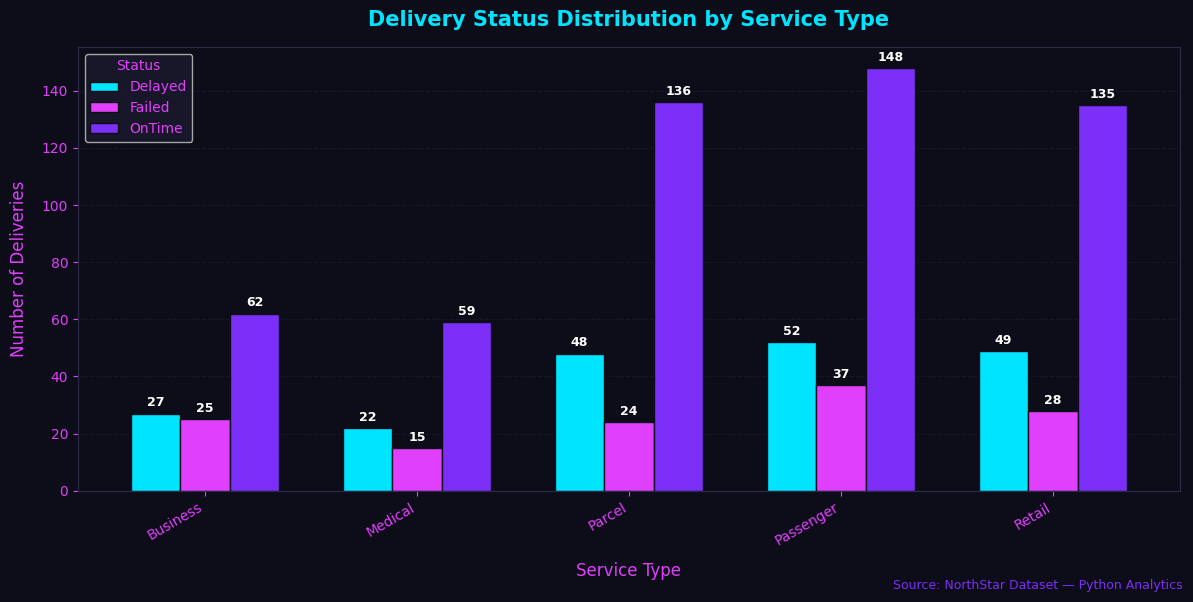

In [ ]:
plt.rcParams.update({
    'figure.facecolor':  '#0d0d1a',
    'axes.facecolor':    '#0d0d1a',
    'axes.edgecolor':    '#2a2a4a',
    'axes.labelcolor':   '#e040fb',
    'xtick.color':       '#e040fb',
    'ytick.color':       '#e040fb',
    'text.color':        '#e040fb',
    'grid.color':        '#1f1f3a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5
})

# Prepare data
ns_status_pivot = ns_unified.groupby(
    ['service_type', 'delivery_status']
).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#00e5ff', '#e040fb', '#7b2ff7']
ns_status_pivot.plot(
    kind='bar', ax=ax,
    color=colors[:len(ns_status_pivot.columns)],
    width=0.7, edgecolor='#0d0d1a'
)

ax.set_title('Delivery Status Distribution by Service Type',
             color='#00e5ff', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Service Type', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Deliveries', fontsize=12, labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Status', facecolor='#1a1a2e',
          labelcolor='#e040fb', title_fontsize=10)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', color='white',
                 fontsize=9, fontweight='bold', padding=3)

plt.figtext(0.99, 0.01, 'Source: NorthStar Dataset — Python Analytics',
            ha='right', color='#7b2ff7', fontsize=9)
plt.tight_layout()
plt.savefig('py_chart1_status_by_service.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


**Chart 1 Interpretation** - Passenger services recorded the highest number of failed deliveries (37),followed by Retail (28) and Business (25). Medical services show the lowest failure count (15), which is likely due to stricter handling protocols. Also, Passenger and Retail also shows the highest OnTime volumes, suggesting that high demand may be contributing to increased failure rates in those categories.

### Chart 2 - Failure rate heatmap by zone and service type

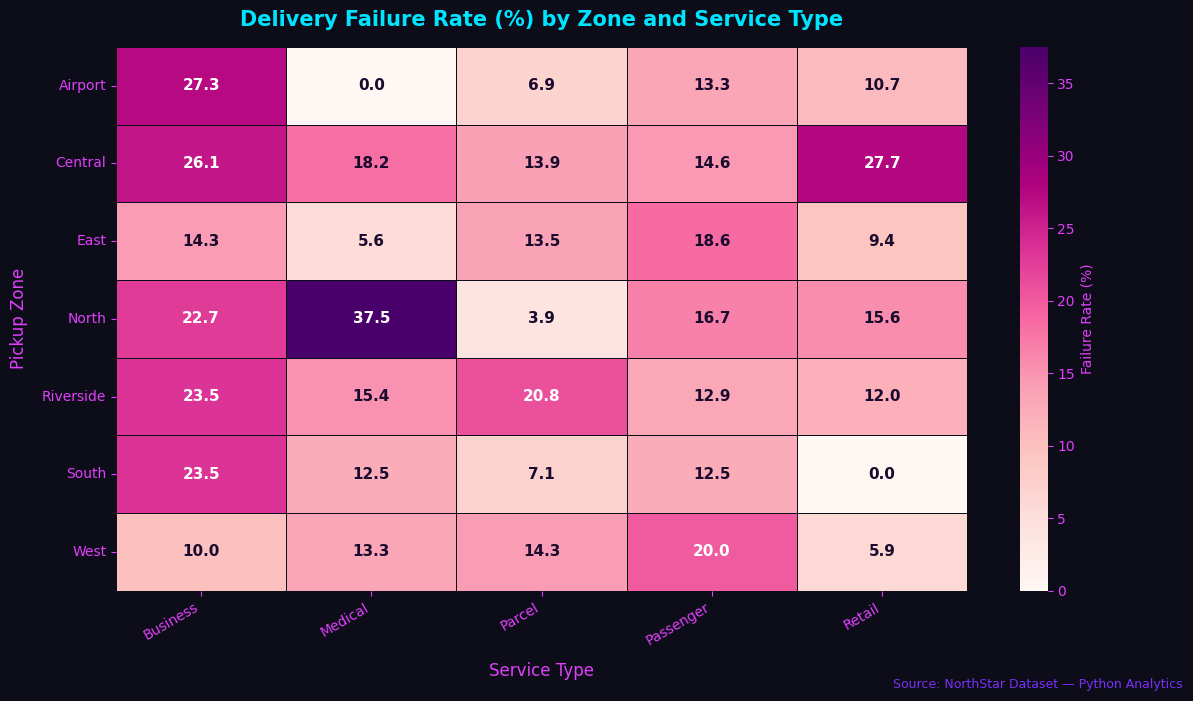

In [ ]:
ns_heatmap = ns_unified.groupby(
    ['pickup_zone', 'service_type']
).agg(
    total=('order_id', 'count'),
    failed=('is_failed', 'sum')
).reset_index()

ns_heatmap['failure_rate'] = (
    ns_heatmap['failed'] / ns_heatmap['total'] * 100
).round(2)

ns_pivot = ns_heatmap.pivot(
    index='pickup_zone',
    columns='service_type',
    values='failure_rate'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    ns_pivot,
    annot=False,          # Turn off default annot, we do it manually
    cmap='RdPu',
    linewidths=0.5,
    linecolor='#0d0d1a',
    ax=ax,
    cbar_kws={'label': 'Failure Rate (%)'}
)

# ── Adaptive text colour ──────────────────────────────────────
threshold = ns_pivot.values.max() / 2  # midpoint of scale
for i in range(ns_pivot.shape[0]):
    for j in range(ns_pivot.shape[1]):
        val = ns_pivot.iloc[i, j]
        text_color = 'white' if val >= threshold else '#1a0a2e'
        ax.text(j + 0.5, i + 0.5, f'{val:.1f}',
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                color=text_color)

ax.set_title('Delivery Failure Rate (%) by Zone and Service Type',
             color='#00e5ff', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Service Type', fontsize=12, labelpad=10)
ax.set_ylabel('Pickup Zone',  fontsize=12, labelpad=10)
ax.tick_params(colors='#e040fb')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.figtext(0.99, 0.01, 'Source: NorthStar Dataset — Python Analytics',
            ha='right', color='#7b2ff7', fontsize=9)
plt.tight_layout()
plt.savefig('py_chart2_heatmap_zone_service.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


**Chart 2 Interpretation** - The heatmap reveals significant variation in failure rates across zones and service types.


*   North-Medical stands out with the highest failure rate at 37.5%, which suggests a critical gap in medical delivery operations in that zone.

*   Business services consistently show high failure rates across most zones, mainly in Airport with 27.3% and Central with 26.1%.


*   Airport-Medical and South-Retail recorded 0.0%, though these may reflect
low order volumes rather than genuine operational excellence.









### Chart 3 - Delivery duration distribution

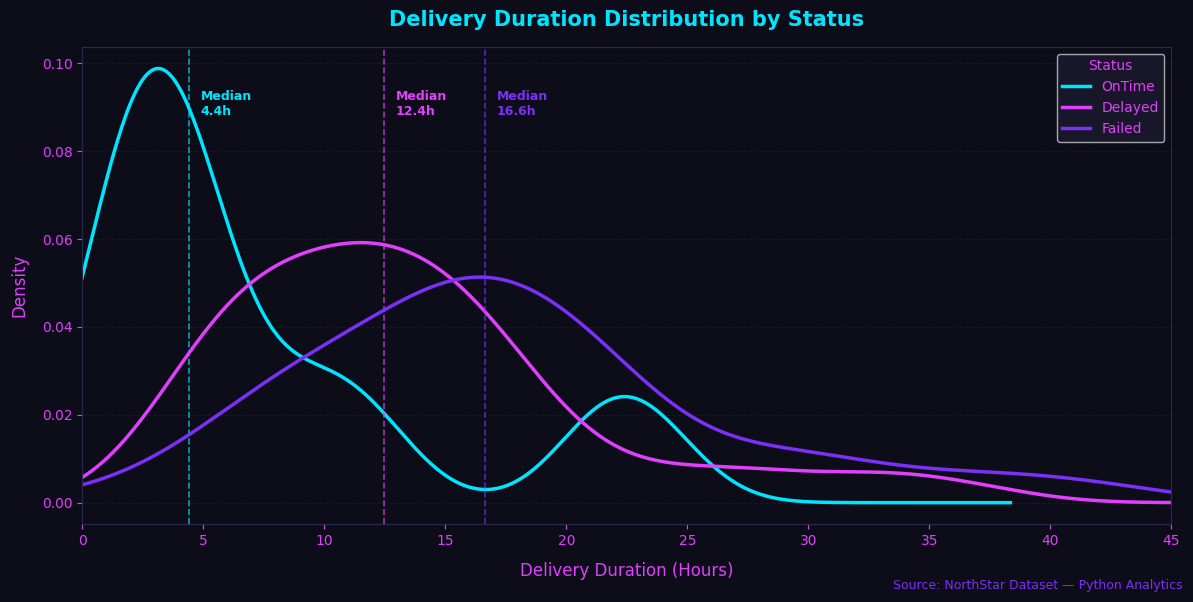

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_map = {
    'OnTime':  '#00e5ff',
    'Delayed': '#e040fb',
    'Failed':  '#7b2ff7'
}

for status, color in colors_map.items():
    subset = ns_deliveries[ns_deliveries['delivery_status'] == status]['delivery_duration_hrs']
    subset.plot.kde(ax=ax, label=status, color=color, linewidth=2.5)
    ax.axvline(subset.median(), color=color, linestyle='--',
               linewidth=1.2, alpha=0.7)

ax.set_title('Delivery Duration Distribution by Status',
             color='#00e5ff', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Delivery Duration (Hours)', fontsize=12, labelpad=10)
ax.set_ylabel('Density', fontsize=12, labelpad=10)
ax.set_xlim(0, 45)
ax.legend(title='Status', facecolor='#1a1a2e',
          labelcolor='#e040fb', title_fontsize=10)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

# Median annotations
for status, color in colors_map.items():
    med = ns_deliveries[ns_deliveries['delivery_status'] == status]['delivery_duration_hrs'].median()
    ax.text(med + 0.5, ax.get_ylim()[1] * 0.85,
            'Median\n' + str(round(med, 1)) + 'h',
            color=color, fontsize=9, fontweight='bold')

plt.figtext(0.99, 0.01, 'Source: NorthStar Dataset — Python Analytics',
            ha='right', color='#7b2ff7', fontsize=9)
plt.tight_layout()
plt.savefig('py_chart3_duration_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


**Chart Interpretation** - The distribution clearly separates the three delivery statuses.


*   OnTime deliveries peak sharply at a median of 4.4 hours which indicates efficient short-duration completions.

*   Delayed deliveries have a broader distribution centred at 12.4 hours.

*   Failed deliveries show the widest and flattest curve with a median of 16.6 hours which is nearly 4x longer than OnTime.

This suggests that prolonged delivery attempts are strongly associated with eventual failure and that a duration threshold of around 10 hours could serve as an early warning indicator for operational teams.

### Chart 4 - Monthly failure thread

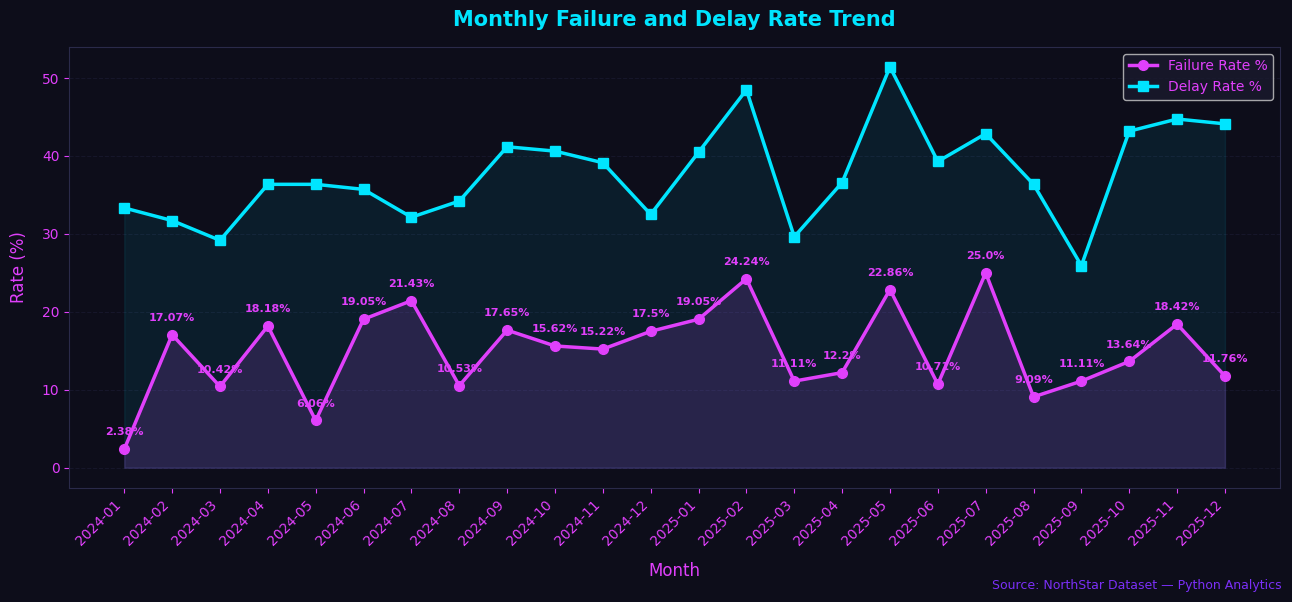

In [ ]:
# Prepare data
ns_monthly = ns_unified.groupby('order_month').agg(
    total_orders   = ('order_id',   'count'),
    failed         = ('is_failed',  'sum'),
    delayed        = ('is_delayed', 'sum')
).reset_index()

ns_monthly['failure_rate_pct'] = (ns_monthly['failed']  / ns_monthly['total_orders'] * 100).round(2)
ns_monthly['delay_rate_pct']   = (ns_monthly['delayed'] / ns_monthly['total_orders'] * 100).round(2)
ns_monthly = ns_monthly.sort_values('order_month')

# Plot
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(ns_monthly['order_month'], ns_monthly['failure_rate_pct'],
        color='#e040fb', linewidth=2.5, marker='o',
        markersize=7, label='Failure Rate %')

ax.plot(ns_monthly['order_month'], ns_monthly['delay_rate_pct'],
        color='#00e5ff', linewidth=2.5, marker='s',
        markersize=7, label='Delay Rate %')

ax.fill_between(ns_monthly['order_month'],
                ns_monthly['failure_rate_pct'],
                alpha=0.15, color='#e040fb')
ax.fill_between(ns_monthly['order_month'],
                ns_monthly['delay_rate_pct'],
                alpha=0.08, color='#00e5ff')

# Value labels
for _, row in ns_monthly.iterrows():
    ax.annotate(str(row['failure_rate_pct']) + '%',
                xy=(row['order_month'], row['failure_rate_pct']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', color='#e040fb', fontsize=8, fontweight='bold')

ax.set_title('Monthly Failure and Delay Rate Trend',
             color='#00e5ff', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('Rate (%)', fontsize=12, labelpad=10)
ax.set_xticklabels(ns_monthly['order_month'], rotation=45, ha='right')
ax.legend(facecolor='#1a1a2e', labelcolor='#e040fb', fontsize=10)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

plt.figtext(0.99, 0.01, 'Source: NorthStar Dataset — Python Analytics',
            ha='right', color='#7b2ff7', fontsize=9)
plt.tight_layout()
plt.savefig('py_chart4_monthly_trend.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

**Chart Interpretation**


*   Failure rates fluctuated significantly throughout 2024 - 2025, peaking to around 25% in July 2025 and 24.24% in February 2025.

*  The delay rate consistently runs much higher than the failure rate (reaching 51% in May 2025), which indicates that a large proportion of deliveries are at risk before they officially fail.

The absence of a downward trend across 24 months suggests that NorthStar has
not implemented effective corrective measures during this period.